<a href="https://colab.research.google.com/github/SergioMartinezL/Gestor-de-horarios/blob/main/ProyectoGestorHorarios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Librerías a utilizar

In [1]:
import pandas as pd
import xlrd
import numpy as np
import csv
import random
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Lectura de las bases de datos

In [9]:
#Leemos la base de datos de los alumnos y profesores e implementamos listas de listas de ellos
archivo = '/alumnos5.csv'
alumnos = np.genfromtxt(archivo, delimiter = ";", skip_header = 1, usemask = True, dtype=int)
numero_de_lineas = len(alumnos) + 1
lista_de_listas_alumnos = [[] for _ in range(numero_de_lineas)]

archivo2 = '/profesores2.csv'
profes = np.genfromtxt(archivo2, delimiter = ";", skip_header = 1, usemask = True, dtype = int)
numero_de_lineas = len(profes) + 1
lista_de_listas_profes= [[] for _ in range(numero_de_lineas)]

#Abrimos el archivo para llenar la lista de listas con la info del archivo 'alumnos'
with open('/alumnos5.csv', newline='') as archivo_csv:
  lector_csv = csv.reader(archivo_csv, delimiter=';')
  k=0
  for fila in lector_csv:
    for obj in fila:
      lista_de_listas_alumnos[k].append(obj)
    k+=1

print("Lista de listas ALUMNOS")
print(lista_de_listas_alumnos[0])
print(lista_de_listas_alumnos[1])
print(lista_de_listas_alumnos[2])
print(lista_de_listas_alumnos[-2])
print(lista_de_listas_alumnos[-1])

#Abrimos el archivo para llenar la lista de listas con la info del archivo 'profes'
with open('/profesores2.csv', newline='') as archivo_csv:
  lector_csv = csv.reader(archivo_csv, delimiter=';')
  k=0
  for fila in lector_csv:
    for obj in fila:
      lista_de_listas_profes[k].append(obj)
    k+=1

print("Lista de listas PROFES")
print(lista_de_listas_profes[0])
print(lista_de_listas_profes[1])
print(lista_de_listas_profes[2])
print(lista_de_listas_profes[-2])
print(lista_de_listas_profes[-1])

Lista de listas ALUMNOS
['\ufeff', 'Algebra Superior', 'Matemáticas', 'Metodologia de la Programacion', 'Formacion Humana y Social', 'Calculo Diferencial', 'Fisica I', 'Algebra L.con Elem.de Geom.Ana', 'Programacion I', 'DHPC', 'Calculo Integral', 'Fisica II', 'Matematicas Discretas', 'Programacion II', 'Ensamblador', 'Ecuaciones Diferenciales', 'Circuitos Electricos', 'Graficacion', 'Estructuras de Datos', 'Probabilidad y Estadistica', 'Circuitos Electronicos', 'Sistemas Operativos I', 'Analisis y Diseno de Algoritm', 'Ingenieria de Software', 'Sistemas Operativos II', 'Modelo de Redes', 'Diseno Digital', 'Bases de Datos para Ingenieria', 'Administracion de Proyectos', 'Redes Inalambricas', 'Mineria de Datos', 'Arquitectura de Computadoras', 'Progra. Concurrente y Paralela', 'Desarrollo de Aplicaciones Web', 'Teoria de Control', 'Administracion de Redes', 'Tec.de Inteligencia Artificial', 'Programacion Distribuida Aplic', 'Dllo. de Aplicaciones Moviles', 'Optativa I', 'Intercom. y Seg

Proyecciones del total de materias a dar en el semestre

**Se puede modificar el "limite_materias_alumno" y el "alumnos_por_materia"**

In [10]:
#Creamos una lista con 0's para la proyeccion de materias
total_de_materias = len(lista_de_listas_alumnos[0])-1
proyeccion_alumnos = [0 for _ in range(total_de_materias)]

#Hacemos la proyeccion de materias por alumno
"""NOTA: El numero de 'limite_materias_alumno' puede cambiar, en este caso es 3 materias por alumno al semestre"""
"""NOTA 2 : Aqui puede cambiar el código para hacer una proyección real donde hay materias predecesoras a otras"""
limite_materias_alumno = 5

for alumno in lista_de_listas_alumnos:
  numero_materia = 0
  contador_materias_alumno = 0
  for materia in alumno:
    if contador_materias_alumno < limite_materias_alumno : #Es el limitador de materias por alumno
      if materia == str(0) : #El 0 significa que aun no ha cursado la materia
        proyeccion_alumnos[numero_materia - 1] += 1
        contador_materias_alumno += 1
    numero_materia +=1

print("Proyeccion ALUMNOS")
print(proyeccion_alumnos)

#Hacemos la proyección final de los alumnos por materia
"""NOTA: el numero de 'alumnos_por_materia' puede cambiar, dependiendo de cuantos alumnos pueden estar en una clase"""
alumnos_por_materia = 40
proyeccion_alumnos_final= []

for i in range(len(proyeccion_alumnos)) :
  proyeccion_alumnos_final.append(proyeccion_alumnos[i]//alumnos_por_materia)

print("Proyeccion ALUMNOS FINAL")
print(proyeccion_alumnos_final)
print("La suma total de materias es : ", sum(proyeccion_alumnos_final))

#Hacemos la proyeccion de materias por profesor
proyeccion_profes = []

for materia in lista_de_listas_profes[-1]:
  if materia != "" :
    proyeccion_profes.append(int(materia))

print("Proyeccion PROFESORES")
print(proyeccion_profes)
print("La suma total de materias es : ", sum(proyeccion_profes))

Proyeccion ALUMNOS
[980, 1037, 1070, 1086, 1361, 404, 362, 357, 353, 330, 326, 330, 323, 324, 331, 339, 327, 321, 530, 290, 290, 305, 303, 277, 286, 272, 274, 276, 210, 210, 215, 210, 203, 159, 149, 152, 145, 157, 80, 171, 222, 210, 190, 181]
Proyeccion ALUMNOS FINAL
[24, 25, 26, 27, 34, 10, 9, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 13, 7, 7, 7, 7, 6, 7, 6, 6, 6, 5, 5, 5, 5, 5, 3, 3, 3, 3, 3, 2, 4, 5, 5, 4, 4]
La suma total de materias es :  379
Proyeccion PROFESORES
[9, 8, 3, 8, 6, 8, 5, 10, 7, 9, 3, 7, 5, 6, 6, 6, 4, 8, 6, 8, 9, 5, 11, 8, 5, 5, 7, 3, 5, 5, 10, 8, 7, 6, 6, 8, 4, 8, 4, 8, 8, 5, 8, 5]
La suma total de materias es :  290


Declaración del número de salones disponibles y horarios

**Se puede modificar "salones", "horarios_salones" y "dias"**

In [ ]:
"""NOTA: por ahora, forzosamente el total de proyeccion de alumnos debe ser igual o mayor al 'total_materias_por_semana' """
salones = 30
horarios_salones = 6
dias = 2

#Hacemos el cálculo del total de materias reales posibles que se pueden impartir en el complejo y/o facultad por semana
total_materias_por_semana = salones * horarios_salones * dias
print("Se pueden impartir en las instalaciones un total de ->", total_materias_por_semana, "<- materias diferentes por semana")

Se pueden impartir en las instalaciones un total de -> 360 <- materias diferentes por semana


Ajuste de la proyeccion de alumnos para que quepan en los salones

In [ ]:
#Checamos si alcanzan los salones para la cantidad de materias que se quieren impartir
salones_sobrantes = 0

if total_materias_por_semana > sum(proyeccion_alumnos_final) : #Significa que hay más salones que clases a dar, entonces se guardará la bandera para utilizarla más adelante
  salones_sobrantes = 1
"""Nota: No se usará por lo mientras"""

print("Proyeccion ALUMNOS FINAL")
print(proyeccion_alumnos_final)

while(total_materias_por_semana < sum(proyeccion_alumnos_final)) : #Si entra, se hace la reducción de materias que tienen más para no sobrepasar
  indice_aux = proyeccion_alumnos_final.index(max(proyeccion_alumnos_final))
  print("Se restará una unidad a la materia : ", indice_aux + 1)
  proyeccion_alumnos_final[indice_aux] -= 1

print("Proyeccion ALUMNOS FINAL REDUCIDA")
print(proyeccion_alumnos_final)
print("Suma un total de -> ", sum(proyeccion_alumnos_final), " <- materias")

NameError: name 'proyeccion_alumnos_final' is not defined

Empalme de la cantidad de materias que van a dar los profesores con la cantidad de materias que requieren los estudiantes

*los que cambiaran de materias serán de abajo hacia arriba, teniendo así prioridad los profesores son con mayor ranking

In [ ]:
"""Nota: 'limite_por_profesor' es la variable que indica cuántas materias puede impartir cada profesor por semestre"""
limite_por_profesor = '5'
for profe in lista_de_listas_profes :
  print(profe[0], " tiene ", profe[-1], " materias")


for i in range(len(proyeccion_alumnos_final)) : # i tiene las iteracios de las materias
  print("\nestamos en la materia numero ",i)

  if (proyeccion_alumnos_final[i] == proyeccion_profes[i]):
    print("son iguales en la materia", i)

  print("proyecion alumnos tiene ", proyeccion_alumnos_final[i], " y el de profes tiene ", proyeccion_profes[i])
  if(proyeccion_alumnos_final[i] != proyeccion_profes[i]) :
    print("entro al primer if")
    aux_total_materia = proyeccion_alumnos_final[i] #num_materias es la cantidad de UNA materia que se proyectan para todos los alumnos
    contador = 0

    for profe in lista_de_listas_profes : # profe tiene las iteraciones en los profes

      if(profe[0] == "\ufeff" or profe[0] == "") : #Esto es para saltar los registros que no sirven
        continue

      if(profe[i+1] != '0' and contador != aux_total_materia) :
        aux_materia_profe = int(profe[i+1])

        while(contador != aux_total_materia and aux_materia_profe != 0) :
          aux_materia_profe -= 1
          contador += 1
          print("es el profe ", profe[0], " y la celda tiene: ", profe[i+1])

          #aqui solo es la opción de cuando ya se han cubierto las clases y un profe quiere dar de más la misma materia
          if(aux_materia_profe != 0 and contador == aux_total_materia) :
            print("\nProfes de más con ", aux_materia_profe, " de más")
            profe[i+1] = str(int(profe[i+1]) - aux_materia_profe)
            print("El total de materias del profe ", profe[0], " es ", profe[-1])
            print("El profe ", profe[0], "queda con ", profe[i+1])
            profe[-1] = str(int(profe[-1]) - aux_materia_profe)
            print("El total de materias del profe ", profe[0], " es ", profe[-1])

      else : #aqui entra cuando hay sobrecupo de profesores, se les quitará materias

        if profe[i+1] != '0' :
          print("el profe ", profe[0], " y antes tenia ", profe[-1])
          j = int(profe[i+1])
          profe[-1] = str(int(profe[-1]) - j)
          print("el profe ", profe[0], " y AHORA tiene ", profe[-1])

        profe[i+1] = str(0)

    #aqui va a entrar cuando hagan falta mas profes para cubrir materias
    #if(contador != aux_total_materia) :
      #print("Contador tiene y num materia tiene", contador, aux_total_materia)
      #print("for inverso")
  #else:
  if(contador != aux_total_materia):
    print("entro al else")
    """for profe2 in reversed(lista_de_listas_profes) :

      if(profe2[0] == "\ufeff" or profe2[0] == "") : #Esto es para saltar los registros que no sirven
        continue

      if(profe2[i+1] != '0' and contador != aux_total_materia and profe2[-1] != limite_por_profesor) : #checamos a los profes del ultimo quien da esa clase, para asignarle otra más y asi acompletar
        print("entro a este if")
        contador += 1
        profe2[-1] = str(int(profe2[-1]) + 1)
        profe2[i+1] = str(int(profe2[i+1]) + 1)
        print(profe2[0], " y tiene ", profe2[i+1])"""

    if(contador != aux_total_materia):
      print("entro al ultimo if")
      #vamos a asignar clases "nuevas" a los profesores que menos tengan, de abajo para arriba
      for profe3 in reversed(lista_de_listas_profes):

        if(profe3[0] == "\ufeff" or profe3[0] == "") : #Esto es para saltar los registros que no sirven
          continue

        if(profe3[-1] == '0' and contador != aux_total_materia):
          contador += 1
          #print(profe3)
          #print("es el profe ", profe3[0], " y 0tiene ", profe3[-1])
          profe3[-1] = str(int(profe3[-1]) + 1)
          profe3[i + 1] = str(int(profe3[i + 1]) + 1)
          print(profe3[0], " y tiene ", profe3[i + 1])

      for profe3 in reversed(lista_de_listas_profes):

        if(profe3[0] == "\ufeff" or profe3[0] == "") : #Esto es para saltar los registros que no sirven
          continue

        if(profe3[-1] != limite_por_profesor and contador != aux_total_materia):
          contador += 1
          #print(profe3)
          #print("es el profe ", profe3[0], " y 0tiene ", profe3[-1])
          profe3[-1] = str(int(profe3[-1]) + 1)
          profe3[i + 1] = str(int(profe3[i + 1]) + 1)
          print(profe3[0], " y tiene ", profe3[i + 1])
      #print("es el profe :", profe)
    #print("No son iguales", i)

  #else :
    #print("son iguales ", i)

NameError: name 'lista_de_listas_profes' is not defined

In [ ]:
for i in range(len(proyeccion_alumnos_final)) :
  #lista_de_listas_profes[-1][]
  aux = 0
  for profe in lista_de_listas_profes :
    if(profe[0] == "\ufeff" or profe[0] == "") : #Esto es para saltar los registros que no sirven
          continue
    aux += int(profe[i+1])
    #print(profe[0], " - ", profe[i+1])
  lista_de_listas_profes[-1][i+1] = str(aux)

  #print("aux tiene ", aux)
  #print("ultimo registro tiene ", lista_de_listas_profes[-1][i+1], " en la materia ", i+1)

NameError: name 'proyeccion_alumnos_final' is not defined

In [ ]:
for profe in lista_de_listas_profes :
  print(profe[0], " tiene ", profe[-1], " materias")

proye_profes2 = []
for materia in lista_de_listas_profes[-1]:
  if materia != "" :
    proye_profes2.append(int(materia))

#proye_profes = lista_de_listas_profes[-1]
print("Profesores y materias")
print(lista_de_listas_profes)
print("proyeccion profes")
print(proye_profes2)
print("proyeccion alumnos")
print(proyeccion_alumnos_final)

NameError: name 'lista_de_listas_profes' is not defined

Ahora empieza la metaheurística. Es donde se le va a asignar un salón a cada una de las materias impartidas

Se crean los identificadores (NRC´S) tanto de profesores-materia como salones-horario

In [ ]:
id_profes = []

#el id de profesor-materia es de la siguiente manera
# 4 digitos para el profesor, 2 digitos para la materia y 1 digito para veces que va a dar la misma materia

for profe in lista_de_listas_profes :
  if(profe[0] == "\ufeff" or profe[0] == "") : #Esto es para saltar los registros que no sirven
    continue
  aux_profe = int(profe[0])*1000
  for i in range(len(profe[1:-2])) :
    if profe[i+1] != "0" :
      aux_materia = (i+1)*10
      aux = int(profe[i+1])
      contador = 1
      while aux != 0 :
        aux_id = aux_profe + aux_materia + contador
        contador += 1
        aux -= 1
        id_profes.append(aux_id)
        #print(aux_id)
print(len(id_profes))
print(id_profes)

id_lugares = []
for i in range(salones) :
  for j in range(horarios_salones) :
    for k in range(dias) :
      aux = (i+1)*1000 + (j+1)*10 + (k+1)
      id_lugares.append(aux)
      #print("ids salones ", aux)
print(len(id_lugares))
print(id_lugares)

NameError: name 'lista_de_listas_profes' is not defined

Creación del cromosoma

In [ ]:
def obtener_cromosoma(lista) :
  copia_lista = lista.copy()
  random.shuffle(copia_lista)
  return copia_lista

In [ ]:
def obtener_posicion_x_profe(elemento, profes) :
  return [indice for indice, valor in enumerate(profes) if valor == elemento]

In [ ]:
def sacar_matriculas_cromosoma(profes) :
  aux = []
  for i in range(len(profes)) :
    aux.append(profes[i]//1000)
  return aux

In [ ]:
def obtener_cromosoma_no_empalme(cromosoma_profe, id_lugares) :
  aux_profes = sacar_matriculas_cromosoma(cromosoma_profe)
  aux3 = sacar_matriculas_cromosoma(id_profes)
  aux_id_profes = list(set(aux3))

  aux_lugares = []
  aux_lugares = obtener_cromosoma(id_lugares)
  #print("cromosoma profe")
  #print(cromosoma_profe)
  #print("cromosoma lugares")
  #print(aux_lugares)

  iteracion = 1
  while True:
    lugares_incorrectos = []
    for i in range(len(aux_id_profes)) :
      posiciones = obtener_posicion_x_profe(aux_id_profes[i], aux_profes)
      #print("es el profe ", aux_id_profes[i], " en las posiciones ", posiciones)
      for j in range(len(posiciones)) :
        for k in range(len(posiciones)) :
          if j != k and aux_lugares[posiciones[j]] % 1000 == aux_lugares[posiciones[k]] % 1000 :
            lugares_incorrectos.append(posiciones[j])
        #print("  materia: ", aux_lugares[posiciones[j]], " : ", aux_lugares[posiciones[j]]%1000)
    #print("incorrectos: ", lugares_incorrectos)
    copia_lista = lugares_incorrectos.copy()
    random.shuffle(copia_lista)
    #print("incorrectos random: ", copia_lista)
    for i in range(len(copia_lista)) :
      auxiliar = aux_lugares[lugares_incorrectos[i]]
      aux_lugares[lugares_incorrectos[i]] = aux_lugares[copia_lista[i]]
      aux_lugares[copia_lista[i]] = auxiliar

    #print("\n iteracion ", iteracion)
    iteracion += 1

    if len(lugares_incorrectos) == 0 :
      return aux_lugares
    if iteracion == 7 :
      aux_lugares = []
      aux_lugares = obtener_cromosoma(id_lugares)
      iteracion = 0

In [ ]:
#teo = obtener_cromosoma(id_profes)
#teo_2 = obtener_cromosoma_no_empalme(teo, id_lugares)

#print(teo)
#print(teo_2)

Creación de la población inicial

In [ ]:
def checar_validez(profes, lugares) :
  aux_profes = sacar_matriculas_cromosoma(profes)
  aux3 = sacar_matriculas_cromosoma(id_profes)
  aux_id_profes = list(set(aux3))

  #aux_lugares = []
  #aux_lugares = obtener_cromosoma(id_lugares)

  while True:
    #lugares_incorrectos = []
    for i in range(len(aux_id_profes)) :
      posiciones = obtener_posicion_x_profe(aux_id_profes[i], aux_profes)
      #print("es el profe ", aux_id_profes[i], " en las posiciones ", posiciones)
      for j in range(len(posiciones)) :
        for k in range(len(posiciones)) :
          if j != k and lugares[posiciones[j]] % 1000 == lugares[posiciones[k]] % 1000 :
            #print("Del profe ", aux_id_profes[i], ", las materias iguales son: ", lugares[posiciones[j]], " y ", lugares[posiciones[k]])
            return False
            lugares_incorrectos.append(posiciones[j])
        #print("  materia: ", aux_lugares[posiciones[j]], " : ", aux_lugares[posiciones[j]]%1000)
    #print("incorrectos: ", lugares_incorrectos)
    return True


In [ ]:
def iniciar_poblacion(numero_poblacion, poblacion_profes, poblacion_lugares, poblacion_puntaje, id_profes, id_lugares):
  #print("\n\n funcon Iniciar poblacion\n\n")
  for i in range(numero_poblacion):
    cromosoma_aux = obtener_cromosoma(id_profes)
    poblacion_profes.append(cromosoma_aux)
    cromosoma_aux_2 = obtener_cromosoma_no_empalme(cromosoma_aux, id_lugares)
    poblacion_lugares.append(cromosoma_aux_2)
    #print(" individuo ", checar_validez(cromosoma_aux, cromosoma_aux_2))
    poblacion_puntaje.append(0)

Función fitness

In [ ]:
def funcion_fitness(cromosoma_profe, cromosoma_lugar, lista_profes, lista_horarios_correctos, aciertos_horarios) :
  #hacemos una lista auxiliar donde tiene profesor, horario elegido y una bandera que nos ayudará a ver si se cumple o no su horario
  matricula_profe_aux = []
  horario_profe_aux = []
  bandera = []
  for profe in lista_profes :
    profe_aux = []
    if(profe[0] == "\ufeff" or profe[0] == "") : #Esto es para saltar los registros que no sirven
      continue
    matricula_profe_aux.append(int(profe[0])) #matricula del profe
    horario_profe_aux.append(int(profe[-2])) #horario que eligio
    bandera.append(0) #bandera en 0, es 1 si es que ya no se cumple su horario

  #se va a buscar por profesor sus clases y checar en que horario se le asigno
  #se evalua con 1 punto por materia en el horario escogido, y con 10 puntos adicionales si cumple TODAS las materias en el HORARIO de un PROFESOR
  puntos = 0

  for i in range(len(cromosoma_profe)) :
    matricula_aux = int(cromosoma_profe[i])//1000 #sacamos matricula del profe

    aux = int(cromosoma_lugar[i])%1000 #sacamos el horario asignado
    horario_aux = aux//10

    posicion = matricula_profe_aux.index(matricula_aux)

    if horario_profe_aux[posicion] == 1 : #1 significa que el profesor prefiere un horario en la mañana, en ese caso seria una de las primeras 3 horas
      if horario_aux <= 3 : #se puede modificar este número
        puntos += 1 #significa que si esta en el horario correcto, así que aumentamos en 1 el puntaje
        lista_horarios_correctos.append(1)

      else :
        bandera[posicion] = 1 #prendemos la bandera de que no está correcto el horario
        lista_horarios_correctos.append(0)

    else :
      if horario_profe_aux[posicion] == 2 :#2 significa que el profesor prefiere clases en la tarde, las ultimas 2 horas por ejemplo
        if horario_aux > 3 :
          puntos += 1
          lista_horarios_correctos.append(1)

        else :
          bandera[posicion] = 1 #prendemos la bandera de que no está correcto el horario
          lista_horarios_correctos.append(0)

      else : #significa que no importa al profesor el horario
        puntos +=1
        lista_horarios_correctos.append(1)

  #se checa todos lor profes que si se les cumplió su horario
  elemento = 0
  repeticiones = bandera.count(elemento)
  puntos += repeticiones * 10
  aciertos_horarios[0] = repeticiones
  return puntos

In [ ]:
def elegir_padres(numero_padres, cromosomas_profes, lista_indices) :
  lista = range(len(cromosomas_profes))
  lista = random.sample(lista, numero_padres)
  for i in range(numero_padres) :
    lista_indices.append(lista[i])

In [ ]:
def verificar_horario_correcto(profe, lugar, lista_profes) :
  matricula = profe//1000 #sacamos matricula del profe
  x = lugar%1000 #sacamos horario asignado en el cromosoma
  horario = x//10

  matricula_profe_aux = []
  horario_profe_aux = []
  for profe in lista_profes :
    profe_aux = []
    if(profe[0] == "\ufeff" or profe[0] == "") : #Esto es para saltar los registros que no sirven
      continue
    matricula_profe_aux.append(int(profe[0])) #matricula del profe
    horario_profe_aux.append(int(profe[-2])) #horario que eligio

  posicion = matricula_profe_aux.index(matricula)
  if horario_profe_aux[posicion] == 1 : #1 significa que el profesor prefiere un horario en la mañana, en ese caso seria una de las primeras 3 horas
    if horario <= 3 :
      #significa que si esta en el horario correcto, asi que le asignamos 1 en el horario_correcto
      return 1
    else :
      return 0
  else :
    if horario_profe_aux[posicion] == 2 :#2 significa que el profesor prefiere clases en la tarde, las ultimas 2 horas por ejemplo
      if horario > 3 :
        #significa que si esta en el horario correcto, asi que le asignamos 1 en el horario_correcto
        return 1
      else :
        return 0
    else :
      #significa que no importa al profesor el horario
      return 1

In [ ]:
def cruza(poblacion_profes, poblacion_lugares, poblacion_puntajes, lista_horarios_correctos, lista_indices_padres, hijos_profes, hijos_lugares, hijos_puntajes, hijos_horarios_correctos) :
  b = 0
  indice = 0
  for iteracion in range(len(lista_indices_padres)) :
    if b == 0 :
      #Aqui entra cuando son los padres impares los que serán modificados (padre 1, padre 3 ..., padre n+1)
      aux = lista_indices_padres[indice]
      aux_padre_2 = lista_indices_padres[indice + 1]

      hijos_profes.append(poblacion_profes[aux].copy())
      hijos_lugares.append(poblacion_lugares[aux].copy())
      hijos_horarios_correctos.append(lista_horarios_correctos[aux].copy())

      #print("El padre original es : ", poblacion_profes[aux])
      #print("La copia hijo es : ", hijos_profes[iteracion])

      for i in range(len(poblacion_profes[aux])) : # en j se itera por elemento del cromosoma
        if hijos_horarios_correctos[indice][i] == 0 :

          #print("Entro al primer if, es donde encuentra un 0 en los horarios en la posicion : ", i)

          #Aqui se busca del segundo padre si esa materia la tiene correcta en el horario
          nrc_profe = poblacion_profes[aux][i]

          #nrc_lugar = poblacion_lugares[aux][i]

          #Se busca el indice en la lista donde coincide el nrc_profe pero ahora del SEGUNDO padre
          posicion = poblacion_profes[aux_padre_2].index(nrc_profe)

          #print("Es la posicion encontrada en el padre 2 del nrc : ", nrc_profe, " la posicion es : " ,posicion)

          #Se verifica si en el SEGUNDO padre tiene correcto el horario
          if lista_horarios_correctos[aux_padre_2][posicion] == 1 :
            #Significa que si estuvo correcto el horario, ahora se checa el salon donde fue asignado

            #print("Entro al if donde encontro que en el segundo padre si esta correcto donde en el primer padre no")

            nrc_lugar = poblacion_lugares[aux_padre_2][posicion]
            #Ahora checamos si ese lugar esta libre para ser cambiado del PRIMER padre
            posicion_2 = hijos_lugares[indice].index(nrc_lugar)
            if hijos_horarios_correctos[indice][posicion_2] == 0 :
              #Significa que si se puede hacer un cambio de salones

              #print("Entro al cambio de salones")
              #print("Lugar primero : ", hijos_lugares[indice][i], " lugar pa cambiar : ", hijos_lugares[indice][posicion_2])

              aux_lugar = hijos_lugares[indice][i]
              hijos_lugares[indice][i] = hijos_lugares[indice][posicion_2]
              hijos_lugares[indice][posicion_2] = aux_lugar


              """Se va a checar si es que no se empalman los salones, de ser así, se regresaran los cambios y quedará como antes estaba los cromosomas"""
              if checar_validez(hijos_profes[indice], hijos_lugares[indice]) :
                #print("Si es valida la cruza xdxdxdd")
                continue
              else :
                #print("\n\nNO es valida la cruza xdxdxdd")
                aux_lugar = hijos_lugares[indice][i]
                hijos_lugares[indice][i] = hijos_lugares[indice][posicion_2]
                hijos_lugares[indice][posicion_2] = aux_lugar


              #print("Despues - lugar primero : ", hijos_lugares[indice][i], " lugar donde cambio : ", hijos_lugares[indice][posicion_2])

              #Se supone que se hizo un cambio al padre PRIMERO en donde ya está correcto, entonces cambiamos su valor en la lista de horarios correctos
              hijos_horarios_correctos[indice][i] = 1
              #Ahora se tiene que checar si el cambio benefició el otro lugar
              chequeo = verificar_horario_correcto(hijos_profes[indice][posicion_2], hijos_lugares[indice][posicion_2], lista_de_listas_profes)
              if chequeo == 1 :
                #Significa que por el que se cambio también es correcto

                #print("Entro al if donde el cambio benefició el cambio")

                hijos_horarios_correctos[indice][posicion_2] = 1

      aux = []
      #hijos_puntajes.append(funcion_fitness(hijos_profes[indice], hijos_lugares[indice], lista_de_listas_profes, hijos_horarios_correctos[indice]))
      aciertos = []
      aciertos.append(0)
      hijos_puntajes.append(funcion_fitness(hijos_profes[indice], hijos_lugares[indice], lista_de_listas_profes, aux, aciertos))

      """print("El hijo ", indice+1, " resulto con esto en verificacion: ", checar_validez(hijos_profes[indice], hijos_lugares[indice]))"""
      #print("El hijo ", indice+1, " resulto con esto en verificacion: ", checar_validez(hijos_profes[indice], hijos_lugares[indice]))

      #print("indice es :", indice)
      #print("tamaños son : ", len(hijos_profes), len(hijos_lugares), len(hijos_horarios_correctos))
      #xd = funcion_fitness(hijos_profes[indice], hijos_lugares[indice], lista_de_listas_profes, hijos_horarios_correctos[indice])
      #print("Puntaje del hijo ", indice, " es : ", xd)
      b = 1
      indice += 1
    else :
      #Aqui entra cuando son los padres pares los que serán modificados (padre 2, padre 4 ..., padre n)
      aux = lista_indices_padres[indice]
      aux_padre_2 = lista_indices_padres[indice - 1]

      hijos_profes.append(poblacion_profes[aux].copy())
      hijos_lugares.append(poblacion_lugares[aux].copy())
      hijos_horarios_correctos.append(lista_horarios_correctos[aux].copy())

      for i in range(len(poblacion_profes[aux])) : # en j se itera por elemento del cromosoma
        if hijos_horarios_correctos[indice][i] == 0 :
          #Aqui se busca del primer padre si esa materia la tiene correcta en el horario
          nrc_profe = poblacion_profes[aux][i]
          #Se busca el indice en la lista donde coincide el nrc_profe pero ahora del PRIMER padre
          posicion = poblacion_profes[aux_padre_2].index(nrc_profe)
          #Se verifica si en el PRIMER padre tiene correcto el horario
          if lista_horarios_correctos[aux_padre_2][posicion] == 1 :
            #Significa que si estuvo correcto el horario, ahora se checa el salon donde fue asignado
            nrc_lugar = poblacion_lugares[aux_padre_2][posicion]
            #Ahora checamos si ese lugar esta libre para ser cambiado del SEGUNDO padre
            posicion_2 = hijos_lugares[indice].index(nrc_lugar)
            if hijos_horarios_correctos[indice][posicion_2] == 0 :
              #Significa que si se puede hacer un cambio de salones
              aux_lugar = hijos_lugares[indice][i]
              hijos_lugares[indice][i] = hijos_lugares[indice][posicion_2]
              hijos_lugares[indice][posicion_2] = aux_lugar

              """Se va a checar si es que no se empalman los salones, de ser así, se regresaran los cambios y quedará como antes estaba los cromosomas"""
              if checar_validez(hijos_profes[indice], hijos_lugares[indice]) :
                #print("Si es valida la cruza xdxdxdd")
                continue
              else :
                #print("\n\nNO es valida la cruza xdxdxdd")
                aux_lugar = hijos_lugares[indice][i]
                hijos_lugares[indice][i] = hijos_lugares[indice][posicion_2]
                hijos_lugares[indice][posicion_2] = aux_lugar

              #Se supone que se hizo un cambio al padre SEGUNDO en donde ya está correcto, entonces cambiamos su valor en la lista de horarios correctos
              hijos_horarios_correctos[indice][i] = 1
              #Ahora se tiene que checar si el cambio benefició el otro lugar
              chequeo = verificar_horario_correcto(hijos_profes[indice][posicion_2], hijos_lugares[indice][posicion_2], lista_de_listas_profes)
              if chequeo == 1 :
                #Significa que por el que se cambio también es correcto
                hijos_horarios_correctos[indice][posicion_2] = 1
      aux = []
      aciertos = []
      aciertos.append(0)
      hijos_puntajes.append(funcion_fitness(hijos_profes[indice], hijos_lugares[indice], lista_de_listas_profes, aux, aciertos))
      b = 0
      #print("El hijo ", indice+1, " resulto con esto en verificacion: ", checar_validez(hijos_profes[indice], hijos_lugares[indice]))
      indice += 1

In [ ]:
def mutacion(hijos_profes, hijos_lugares, hijos_puntajes, hijos_horarios_correctos) :
  for i in range(len(hijos_profes)) :
    posiciones = []
    #print("total :", hijos_horarios_correctos[i])
    for k in range(len(hijos_horarios_correctos[i])) :
      if hijos_horarios_correctos[i][k] == 0 :
        posiciones.append(k)
    #print("Posiciones con 0's = ", posiciones)

    pos_aux = posiciones.copy()
    #print("\nantes del random : ", pos_aux)
    random.shuffle(pos_aux)
    #print("posiciones random = ", pos_aux)
    #Se crean 2 listas de posiciones, una con las posiciones normales y otra ordenada de manera random, entonces se cambiaran entre si

    for j in range(len(pos_aux)) :
      #print("cambio ", hijos_lugares[i][pos_aux[j]], " con posicion ", pos_aux[j], " con ", hijos_lugares[i][posiciones[j]], " con posicion ", posiciones[j])
      aux = hijos_lugares[i][pos_aux[j]]
      hijos_lugares[i][pos_aux[j]] = hijos_lugares[i][posiciones[j]]
      hijos_lugares[i][posiciones[j]] = aux

      if checar_validez(hijos_profes[i], hijos_lugares[i]) :
        chequeo = verificar_horario_correcto(hijos_profes[i][pos_aux[j]], hijos_lugares[i][pos_aux[j]], lista_de_listas_profes)
        if chequeo == 1 :
          #Significa que por el que se cambio también es correcto
          hijos_horarios_correctos[i][pos_aux[j]] = 1

        chequeo2 = verificar_horario_correcto(hijos_profes[i][posiciones[j]], hijos_lugares[i][posiciones[j]], lista_de_listas_profes)
        if chequeo2 == 1 :
          #Significa que por el que se cambio también es correcto
          hijos_horarios_correctos[i][posiciones[j]] = 1
      else :
        aux = hijos_lugares[i][pos_aux[j]]
        hijos_lugares[i][pos_aux[j]] = hijos_lugares[i][posiciones[j]]
        hijos_lugares[i][posiciones[j]] = aux

    aux = []
    aciertos = []
    aciertos.append(0)
    hijos_puntajes[i] = funcion_fitness(hijos_profes[i], hijos_lugares[i], lista_de_listas_profes, aux, aciertos)


In [ ]:
def remplazo(poblacion_profes, poblacion_lugares, poblacion_puntajes, lista_horarios_correctos, hijos_profes, hijos_lugares, hijos_puntajes, hijos_horarios_correctos):
  pos_poblacion = busca_peor(poblacion_puntajes)
  pos_hijos = busca_mejor(hijos_puntajes)

  #primer caso, si es que el mejor de los hijos no supera al peor de la poblacion
  if poblacion_puntajes[pos_poblacion] > hijos_puntajes[pos_hijos] :
    print("En esta generación no se obtuvo un hijo que sea mejor que alguno de la población :(\n")
  else:
    hijos_mejor_a_peor = busca_mejor_a_peor(hijos_puntajes)
    for i,j in enumerate(hijos_mejor_a_peor): #en j van las posiciones según se ordenó de mejor a peor, i es solo iterador
      pos_peor_poblacion = busca_peor(poblacion_puntajes) #devuelve la posicion del peor en poblacion
      if hijos_puntajes[j] > poblacion_puntajes[pos_peor_poblacion] :
        #Se hace el reemplazo del integrante de la población por uno de los hijos
        bandera = 0
        for k in range(len(poblacion_lugares)) :
          if hijos_lugares[j] == poblacion_lugares[k] :
            bandera = 1
        if bandera == 0 :
          print("Será remplazado el cromosoma ", pos_peor_poblacion + 1, " por el hijo ", j + 1)
          poblacion_profes[pos_peor_poblacion] = hijos_profes[j]
          poblacion_lugares[pos_peor_poblacion] = hijos_lugares[j]
          poblacion_puntajes[pos_peor_poblacion] = hijos_puntajes[j]
          lista_horarios_correctos[pos_peor_poblacion] = hijos_horarios_correctos[j]

In [ ]:
#Funcion que busca el cromosoma con peor precision y devuelve su posicion
def busca_peor(lista_puntajes):
  peor = lista_puntajes[0]
  posicion = 0
  for i in range(len(lista_puntajes)):
    if lista_puntajes[i] < peor :
      peor = lista_puntajes[i]
      posicion = i
  return posicion

In [ ]:
#Funcion que busca el cromosoma con mejor precision y devuelve su posicion
def busca_mejor(lista_puntajes):
  mejor = lista_puntajes[0]
  posicion = 0
  for i in range(len(lista_puntajes)):
    if lista_puntajes[i] > mejor :
      mejor = lista_puntajes[i]
      posicion = i
  return posicion

In [ ]:
#funcion que devuelve un arreglo ordenado de mejor a peor en precision
def busca_mejor_a_peor(lista_puntajes):
  visitado = np.zeros(len(lista_puntajes))
  orden = []
  aux = busca_peor(lista_puntajes)

  while len(orden) < len(lista_puntajes):
    mejor = lista_puntajes[aux]
    posicion = aux
    for i in range(len(lista_puntajes)):
      if lista_puntajes[i] >= mejor and visitado[i] == 0:
        mejor = lista_puntajes[i]
        posicion = i
    orden.append(posicion)
    visitado[posicion] = 1
  return orden

In [ ]:
#Se indica el numero de poblacion del algoritmo y el numero de generaciones
numero_poblacion = 10
numero_generaciones = 10
padres_por_generacion = 4
numero_poblaciones = 30

#Hacemos el ciclo que nos va a dar el resultado de 10 poblaciones diferentes
poblacion_actual = 0

grafica = []
final_profes = []
final_lugares = []
final_puntajes = []

while poblacion_actual <numero_poblaciones :
  poblacion_actual += 1

  #poblacion va a tener la poblacion, precisiones va a tener las precisiones de cada individuo de la población correspondiente
  poblacion_profes = []
  poblacion_lugares = []
  poblacion_puntajes = []

  #creamos la población inicial
  iniciar_poblacion(numero_poblacion, poblacion_profes, poblacion_lugares, poblacion_puntajes, id_profes, id_lugares)

  lista_horarios_correctos = []
  for i in range(len(poblacion_profes)) :
    lista_horarios_correctos_aux = []
    aciertos = []
    aciertos.append(0)
    poblacion_puntajes[i] = funcion_fitness(poblacion_profes[i], poblacion_lugares[i], lista_de_listas_profes, lista_horarios_correctos_aux, aciertos)
    lista_horarios_correctos.append(lista_horarios_correctos_aux)

  #Inicia el proceso de generaciones
  generacion_actual = 0
  #grafica = []

  while (generacion_actual < numero_generaciones) :

    generacion_actual += 1
    print("\n\n -. -. -. Generación ", generacion_actual, " .- .- .- ")
    print("\n - - - Población Actual - - - \n")
    for i in range(len(poblacion_profes)) :
      print("\nCromosoma_Profes ", i + 1, " es: ", poblacion_profes[i])
      print("Cromosoma_Lugares ", i + 1, " es: ", poblacion_lugares[i])
      print("\tPrecisión del cromosoma es: ", poblacion_puntajes[i])

  #Elegir padres
    print("\n -. -. -. Elección de Padres .- .- .-")
    lista_indices_padres = []

    elegir_padres(padres_por_generacion, poblacion_profes, lista_indices_padres)

    for i in range(len(lista_indices_padres)) :
      print("Se eligió como padre al cromosoma ", lista_indices_padres[i] + 1)

  #Cruzar
    print("\n -. -. -. Cruza de Padres .- .- .-")
    hijos_profes = []
    hijos_lugares = []
    hijos_puntajes = []
    hijos_horarios_correctos = []

    cruza(poblacion_profes, poblacion_lugares, poblacion_puntajes, lista_horarios_correctos, lista_indices_padres, hijos_profes, hijos_lugares, hijos_puntajes, hijos_horarios_correctos)

    for i in range(len(hijos_profes)) :
      print("\nCromosoma_Hijo_Profes ", i + 1, " es: ", hijos_profes[i])
      print("Cromosoma_Hijo_Lugares ", i + 1, " es: ", hijos_lugares[i])
      print("\tPrecisión del cromosoma hijo es: ", hijos_puntajes[i])


  #Mutar
    print("\n -. -. -. Mutación .- .- .-")

    mutacion(hijos_profes, hijos_lugares, hijos_puntajes, hijos_horarios_correctos)

    for i in range(4) :
      print("\nHijo_Mutado_Profes ", i + 1, " es: ", hijos_profes[i])
      print("Hijo_Mutado_Lugares ", i + 1, " es: ", hijos_lugares[i])
      print("\tPrecisión del hijo mutado es: ", hijos_puntajes[i])
      #print("\tSu validez es: ", checar_validez(hijos_profes[i], hijos_lugares[i]))

  #Remplazar
    print("\n -. -. -. Remplazo -. -. -.")

    remplazo(poblacion_profes, poblacion_lugares, poblacion_puntajes, lista_horarios_correctos, hijos_profes, hijos_lugares, hijos_puntajes, hijos_horarios_correctos)

  #Población resultante de la generación
    #grafica.append(poblacion_puntajes[busca_mejor(poblacion_puntajes)])
    print("\n -. -. -. Poblacion Resultante de la Generación -. -. -.")
    for i in range(len(poblacion_profes)) :
      print("\nCromosoma_Profes ", i + 1, " es: ", poblacion_profes[i])
      print("Cromosoma_Lugares ", i + 1, " es: ", poblacion_lugares[i])
      print("\tPrecisión del cromosoma es: ", poblacion_puntajes[i])

  #Impresion del resultado final de la poblacion en cuestion
  print("\n\n -. -. -. Poblacion Final -. -. -.")
  for i in range(len(poblacion_profes)) :
    print("\nCromosoma_Profes ", i, " es: ", poblacion_profes[i])
    print("Cromosoma_Lugares ", i, " es: ", poblacion_lugares[i])
    print("\tPrecisión del cromosoma es: ", poblacion_puntajes[i])

  print("\n\n -. -. -. Elección de la mejor solución -. -. -.")
  pos_final = busca_mejor(poblacion_puntajes)
  print("El mejor cromosoma es: ", poblacion_puntajes[pos_final])
  print("Profes : ", poblacion_profes[pos_final])
  print("Lugares : ", poblacion_lugares[pos_final])
  print("La precision del mejor cromosoma es: ", poblacion_puntajes[pos_final])

  final_profes.append(poblacion_profes[pos_final])
  final_lugares.append(poblacion_lugares[pos_final])
  final_puntajes.append(poblacion_puntajes[pos_final])

  grafica.append(poblacion_puntajes[pos_final])



NameError: name 'id_lugares' is not defined

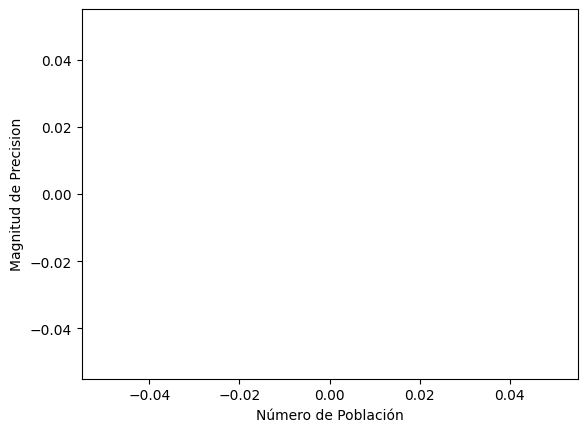

In [ ]:
plt.xlabel("Número de Población")
plt.ylabel("Magnitud de Precision")
plt.plot(grafica)

In [ ]:
print("\n\n -. -. -. Elección de la mejor solución FINAL -. -. -.")
pos_final = busca_mejor(final_puntajes)
print("El mejor cromosoma es el número : ", pos_final)
print("Profes : ", final_profes[pos_final])
print("Lugares : ", final_lugares[pos_final])
print("Precision : ", final_puntajes[pos_final])
print("Validez : ", checar_validez(final_profes[pos_final], final_lugares[pos_final]) )



 -. -. -. Elección de la mejor solución FINAL -. -. -.


IndexError: list index out of range

Se saca el porcentaje de efectividad de la mejor solución

In [ ]:
#Efectividad
aciertos_horarios = []
aciertos_horarios.append(0)
funcion_fitness(final_profes[pos_final], final_lugares[pos_final], lista_de_listas_profes, lista_horarios_correctos_aux, aciertos_horarios)
print("El total de profesores es : ", len(lista_de_listas_profes)-2)
print("El total de aciertos respetando el horario elegido por cada profesor es : ", aciertos_horarios[0])
aux = final_puntajes[pos_final] - (aciertos_horarios[0]*10)
efectividad = ( 100/len(final_profes[0]) ) * aux
print("La efectividad de la solución es : ", efectividad, "%")

NameError: name 'pos_final' is not defined

In [ ]:
from ast import Break
aux_profes = sacar_matriculas_cromosoma(final_profes[pos_final])
aux3 = sacar_matriculas_cromosoma(id_profes)
aux_id_profes = list(set(aux3))

#aux_lugares = []
#aux_lugares = obtener_cromosoma(id_lugares)
#print("cromosoma profe")
#print(cromosoma_profe)
#print("cromosoma lugares")
#print(aux_lugares)

while True :
  lugares_incorrectos = []
  for i in range(len(aux_id_profes)) :
    posiciones = obtener_posicion_x_profe(aux_id_profes[i], aux_profes)
    print("es el profe ", aux_id_profes[i], " en las posiciones ", posiciones)
    for j in range(len(posiciones)) :
      for k in range(len(posiciones)) :
        if j != k and final_lugares[pos_final][posiciones[j]] % 1000 == final_lugares[pos_final][posiciones[k]] % 1000 :
          lugares_incorrectos.append(posiciones[j])
      print("  materia: ", final_lugares[pos_final][posiciones[j]], " : ", final_lugares[pos_final][posiciones[j]]%1000)
  break

NameError: name 'pos_final' is not defined

In [ ]:
def estilo_fila_excel(fila_a_cambiar, color_fuente, color_fondo, color_borde) :
  fuente = Font(color=color_fuente)  # Color fuente
  borde_izquierdo = Side(style="medium", color=color_borde)  # color borde
  borde_derecho = Side(style="medium", color=color_borde)   # color borde
  borde_superior = Side(style="medium", color=color_borde)  # color borde
  borde_inferior = Side(style="medium", color=color_borde)  # color borde

  for columna in hoja.iter_cols(min_row=fila_a_cambiar, max_row=fila_a_cambiar):
    for celda in columna:
      celda.fill = PatternFill(start_color=color_fondo, end_color=color_fondo, fill_type="solid")  # Color fondo
      celda.font = fuente
      borde = Border(left=borde_izquierdo, right=borde_derecho, top=borde_superior, bottom=borde_inferior)
      celda.border = borde


In [ ]:
!pip install reportlab

In [ ]:
import openpyxl
from openpyxl.styles import PatternFill
from openpyxl.styles import Font
from openpyxl.styles import Border, Side

from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph
from reportlab.lib.styles import getSampleStyleSheet


"""excel"""

# Crea un nuevo libro de trabajo (workbook)
horarios = openpyxl.Workbook()

hoja = horarios.active
hoja["A1"] = "Hola, es la impresión de los horarios de los profesores :)"

# Selecciona la hoja activa (por defecto, la primera hoja)
contador = 0

#Lista de los lunes
lunes = []

for i in range(len(lista_de_listas_profes[1:-1])) :
  hoja = horarios.create_sheet(lista_de_listas_profes[i + 1][0])
  profe = lista_de_listas_profes[i + 1][0]
  hoja["A1"] = "Horario del profesor " + profe
  hoja["A2"] = "Horas"
  hoja["A3"] = "7:00 - 8:00"
  hoja["A4"] = "8:00 - 9:00"
  hoja["A5"] = "9:00 - 10:00"
  hoja["A6"] = "10:00 - 11:00"
  hoja["A7"] = "11:00 - 12:00"
  hoja["A8"] = "12:00 - 13:00"
  hoja["A9"] = "13:00 - 14:00"
  hoja["A10"] = "14:00 - 15:00"
  hoja["A11"] = "15:00 - 16:00"
  hoja["A12"] = "16:00 - 17:00"
  hoja["A13"] = "17:00 - 18:00"
  hoja["A14"] = "18:00 - 19:00"

  hoja["B2"] = "Lunes"
  hoja["C2"] = "Martes"
  hoja["D2"] = "Miercoles"
  hoja["E2"] = "Jueves"
  hoja["F2"] = "Viernes"

  fila_a_cambiar = 2
  estilo_fila_excel(fila_a_cambiar, "FFFFFF", "CB4335", "78281F")

  for j in range(len(final_profes[pos_final])) :
    cadena = str(final_profes[pos_final][j]//1000)
    cadena2 = str(final_profes[pos_final][j])
    if profe in cadena :
      #Sacamos materia, horario, salón y día
      contador += 1
      #print("Contador ", contador)
      #print("Es el profe ", final_profes[pos_final][j])
      #print("Es el lugar ", final_lugares[pos_final][j])
      aux = int(final_profes[pos_final][j])%1000
      aux2 = aux//10

      aux_salon = final_lugares[pos_final][j]//1000
      aux_materia = "Materia: " + lista_de_listas_alumnos[0][aux2] + " Salón: " + str(aux_salon)
      #aux_materia = "Materia " + str(aux2) + " Salón " + str(aux_salon)

      aux = int(final_lugares[pos_final][j])%1000

      aux_horario = aux//10
      aux_dia = aux%10

      #Se imprimen los lunes
      if aux_dia == 1 :
        celda = hoja.cell(row = (aux_horario * 2) + 1, column = aux_dia + 1)
        celda.value = aux_materia
      else :
        celda = hoja.cell(row = (aux_horario * 2) + 2, column = aux_dia)
        celda.value = aux_materia

      #Se imprime la materia en el dia y horario que le tocó
      celda = hoja.cell(row = (aux_horario * 2) + 1, column = aux_dia + 2)
      celda.value = aux_materia
      celda = hoja.cell(row = (aux_horario * 2) + 2, column = aux_dia + 2)
      celda.value = aux_materia

      celda = hoja.cell(row = (aux_horario * 2) + 1, column = aux_dia + 4)
      celda.value = aux_materia
      celda = hoja.cell(row = (aux_horario * 2) + 2, column = aux_dia + 4)
      celda.value = aux_materia

  for columna in hoja.columns:
    max_length = 0
    column = columna[0].column_letter
    for celda in columna:
      try:
        if len(str(celda.value)) > max_length:
          max_length = len(celda.value)
      except:
        pass
    adjusted_width = (max_length) * 1.2
    hoja.column_dimensions[column].width = adjusted_width

  limite = hoja.max_row
  while fila_a_cambiar < limite :
    fila_a_cambiar += 1
    if fila_a_cambiar%2 != 0 :
      estilo_fila_excel(fila_a_cambiar, "000000", "FADBD8", "78281F")
    else :
      estilo_fila_excel(fila_a_cambiar, "000000", "F5B7B1", "78281F")

# Guarda el archivo de Excel
horarios.save("Horarios.xlsx")


"""PDF"""

"""# Datos para el contenido del PDF (por ejemplo, una tabla)
encabezado = ["Nombre", "Edad", "Ciudad"]
fila1 = ["Juan", "26", "Madrid"]
fila2 = ["María", "30", "Barcelona"]
data = []
    #encabezado,
    #fila1,
    #fila2,
#]
data.append(encabezado)
data.append(fila1)
data.append(fila2)"""

#Aqui se guarda toda la información que construira el pdf
contenido = []

#Se hace el titulo del PDF  y se le da estilo
styles = getSampleStyleSheet()
titulo = "Programación academica 2023"
titulo_texto = Paragraph(titulo, styles['Title'])
contenido.append(titulo_texto)

for contador_materia in range(1,len(proyeccion_profes)+1) : #vamos a recorrer entre las materias con este for
  #se ingresa el nombre de la materia
  styles = getSampleStyleSheet()
  #titulo_materia = "Materia: " + str(contador_materia)
  titulo_materia = "Materia: " + str(lista_de_listas_alumnos[0][contador_materia])
  titulo_materia_texto = Paragraph(titulo_materia, styles['Heading2'])
  contenido.append(titulo_materia_texto)

  #en tabla[] va a construir la informacion de profesores, salones, dias y horarios de una sola materia
  tabla = []
  encabezado = ["NRC", "Días", "Hora", "Profesor", "Salón"]
  tabla.append(encabezado)

  for materia in range(len(final_profes[pos_final])) : #vamos a recorrer entre la solución final todas las materias y buscar coincidencias de materia por materia
    #obtenemos la materia en el recorrido y vamos a verificar si hay coincidencia con el numero de materia del for de arriba
    aux = int(final_profes[pos_final][materia])%1000
    coincidencia_materia = aux//10

    if contador_materia == coincidencia_materia : #se checa si es igual la materia
      #en renglon[] vamos a construir un renglon de la tabla
      renglon = []

      #Obtenemos el salon, horario y dia de ese renglon
      aux = final_lugares[pos_final][materia]%1000
      aux_salon = final_lugares[pos_final][materia]//1000
      aux_horario = aux//10
      aux_dia = aux%10

      if aux_dia == 1 : #Son los lunes, martes y jueves
        #NRC
        renglon.append(final_lugares[pos_final][materia])
        #dias
        renglon.append("L")
        #hora
        cadena = str((aux_horario * 2) + 5) + ":00-" + str((aux_horario * 2) + 6) + ":00"
        renglon.append(cadena)
        #profesor
        cadena = str(int(final_profes[pos_final][materia])//1000)
        renglon.append(cadena)
        #salon
        renglon.append(aux_salon)

        #Se ingresa este renglon del lunes a la tabla
        print("renglon lunes: ", renglon)
        tabla.append(renglon)
        print("tabla: ", tabla)

        #Se limpia la tabla_materia_aux para ingresar el de martes y jueves
        renglon = []

        #Se ingresan los datos de martes y jueves
        #NRC
        renglon.append(final_lugares[pos_final][materia])
        #dias
        renglon.append("A J")
        #hora
        #cadena = "Hora " + str((aux_horario * 2) - 1) + " y Hora " + str(aux_horario * 2)
        cadena = str((aux_horario * 2) + 5) + ":00-" + str((aux_horario * 2) + 7) + ":00"
        renglon.append(cadena)
        #profesor
        cadena = str(int(final_profes[pos_final][materia])//1000)
        renglon.append(cadena)
        #salon
        renglon.append(aux_salon)

        #Se ingresa este renglon del martes y jueves a la tabla
        print("renglon martes y jueves: ", renglon)
        tabla.append(renglon)
        print("tabla: ", tabla)

      else : #Son los lunes, miercoles y viernes
        #NRC
        renglon.append(final_lugares[pos_final][materia])
        #dias
        renglon.append("L")
        #hora
        #cadena = "Hora " + str((aux_horario * 2))
        cadena = str((aux_horario * 2) + 6) + ":00-" + str((aux_horario * 2) + 7) + ":00"
        renglon.append(cadena)
        #profesor
        cadena = str(int(final_profes[pos_final][materia])//1000)
        renglon.append(cadena)
        #salon
        renglon.append(aux_salon)

        #Se ingresa este renglon del lunes a la tabla
        print("renglon lunes dia 2: ", renglon)
        tabla.append(renglon)
        print("tabla: ", tabla)

        #Se limpia la tabla_materia_aux para ingresar el MIERCOLES Y VIERNES
        renglon = []

        #Se ingresan los datos de MIERCOLES Y VIERNES
        #NRC
        renglon.append(final_lugares[pos_final][materia])
        #dias
        renglon.append("M V")
        #hora
        #cadena = "Hora " + str((aux_horario * 2) - 1) + " y Hora " + str(aux_horario * 2)
        cadena = str((aux_horario * 2) + 5) + ":00-" + str((aux_horario * 2) + 7) + ":00"
        renglon.append(cadena)
        #profesor
        cadena = str(int(final_profes[pos_final][materia])//1000)
        renglon.append(cadena)
        #salon
        renglon.append(aux_salon)

        #Se ingresa este renglon dE MIERCOLES Y VIERNES a la tabla
        print("renglon miercoles y viernes: ", renglon)
        tabla.append(renglon)
        print("tabla: ", tabla)

  print("TABLA FINAL MATERIA: ", tabla)
  tabla_materia = Table(tabla, colWidths=[50, 50, 100, 150, 100])
  tabla_materia.setStyle(TableStyle([('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#21618C')),
    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
    ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
    ('BACKGROUND', (0, 1), (-1, -1), colors.lightblue),
    ('GRID', (0, 0), (-1, -1), 1, colors.black)]))
  contenido.append(tabla_materia)

# Crear un objeto SimpleDocTemplate con el nombre del archivo de salida y el tamaño de página (por ejemplo, carta)
pdf_filename = "reporte.pdf"
doc = SimpleDocTemplate(pdf_filename, pagesize=letter)

# Construir el PDF
doc.build(contenido)

ModuleNotFoundError: No module named 'reportlab'

In [ ]:
print("Ahora si FIN DEL PROYECTO :) 19/07/2023 UN MIÉRCOLES EN HUAMANTLA TLAXCALA")

Ahora si FIN DEL PROYECTO :) 19/07/2023 UN MIÉRCOLES EN HUAMANTLA TLAXCALA


In [ ]:
print("Finalmente terminado ahora si el PROYECTO :) 25/07/2023 UN MARTES EN HUAMANTLA TLAXCALA")
print("Solo hace faltan hacer pruebas")

Finalmente terminado ahora si el PROYECTO :) 25/07/2023 UN MARTES EN HUAMANTLA TLAXCALA
Solo hace faltan hacer pruebas
